Saving Untitled form.csv.zip to Untitled form.csv (1).zip


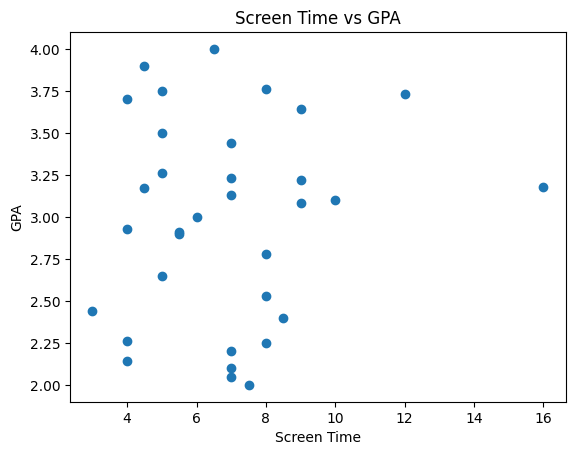

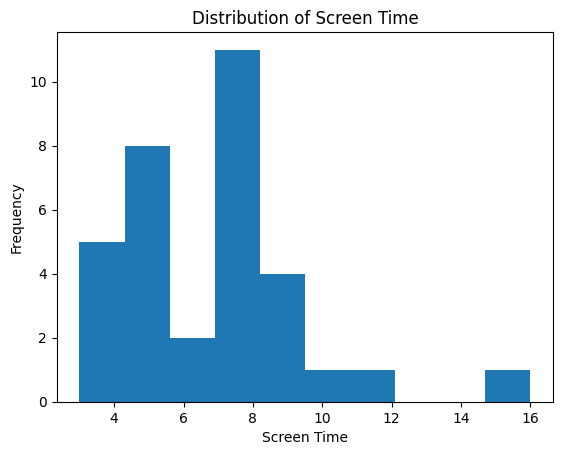

Correlation Matrix:
             gpa    screen     study     sleep
gpa     1.000000  0.104564  0.308370 -0.192079
screen  0.104564  1.000000  0.383889 -0.172914
study   0.308370  0.383889  1.000000 -0.185806
sleep  -0.192079 -0.172914 -0.185806  1.000000

Hypothesis Test (Screen vs GPA)
Correlation: 0.10456411588707146
P-value: 0.5625181075517321

Hypothesis Test (Study vs GPA)
Correlation: 0.3083696202829567
P-value: 0.08081473697354219


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import re
from scipy.stats import pearsonr


from google.colab import files
uploaded = files.upload()

df = pd.read_csv("Untitled form.csv")


gpa_col = "What is your current GPA?\n(Please enter as a number, e.g., 3.25)"
screen_col = "On average, how many hours do you spend on screens daily?\n(Include phone, computer, tablet, etc.)"
sleep_col = "  On average, how many hours do you sleep per night?  "
study_col = "  On average, how many hours do you study per day outside of classes?  "


def clean(x):
    x = str(x).strip().lower()
    nums = re.findall(r"\d+\.?\d*", x)
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return None


df["gpa"] = df[gpa_col].apply(clean)
df["screen"] = df[screen_col].apply(clean)
df["sleep"] = df[sleep_col].apply(clean)
df["study"] = df[study_col].apply(clean)


df = df[(df["gpa"] >= 0) & (df["gpa"] <= 4)]
df = df[(df["screen"] >= 0) & (df["screen"] <= 24)]
df = df.dropna()




plt.scatter(df["screen"], df["gpa"])
plt.xlabel("Screen Time")
plt.ylabel("GPA")
plt.title("Screen Time vs GPA")
plt.show()


plt.hist(df["screen"])
plt.title("Distribution of Screen Time")
plt.xlabel("Screen Time")
plt.ylabel("Frequency")
plt.show()



print("Correlation Matrix:")
print(df[["gpa", "screen", "study", "sleep"]].corr())



corr, p_value = pearsonr(df["screen"], df["gpa"])

print("\nHypothesis Test (Screen vs GPA)")
print("Correlation:", corr)
print("P-value:", p_value)



corr2, p_value2 = pearsonr(df["study"], df["gpa"])

print("\nHypothesis Test (Study vs GPA)")
print("Correlation:", corr2)
print("P-value:", p_value2)

The results show that there is no strong relationship between screen time and GPA.

The hypothesis test indicates that this relationship is not statistically significant.

However, study time shows a stronger relationship with GPA.